# dr_evt 01: repo tour and first simulation

First of four sessions on LLNL's `dr_evt`. This one answers: what is dr_evt, how is the
code laid out, how did we build it on this Mac, and what does one simulation look like end
to end. Sessions 02-04 cover the Python streaming API, the gRPC client/server, and a mini
federation of platforms driven by a router (the seed of our auction client).

Read it top to bottom, run every cell, then try the exercises at the end.

## What dr_evt is

dr_evt is a discrete-event simulator of **one HPC cluster's batch scheduler**: a C++17
core implementing FCFS ordering with EASY or conservative backfilling (plus SJF/LJF
priorities), verified against a from-scratch Python reference scheduler. Jobs enter either
in **batch mode** (load a whole trace, run to the end) or in **streaming mode** (append
jobs one at a time and advance the simulated clock yourself). The streaming API is exposed
in-process through pybind11 (`import dr_evt`) and over the network through a gRPC
bidirectional stream (`dr_evt_server`), so a client in another process or on another
machine can feed jobs and read state.

It is developed on feature branches merged through GitHub PRs, tested
by shell-driven suites in GitHub Actions, and documented on ReadTheDocs. The style guide
is `README_coding_style.txt`.

The mental model to keep: **one `Simulation` = one cluster** = one integer `total_nodes`,
one wait queue, one event queue. Nodes have no identity or speed. There is no multi-cluster
object inside the C++ core; a federation is N simulations driven by one client. That client
is what we are going to build.

In [1]:
from pathlib import Path
import subprocess, sys, os, re, tempfile
import pandas as pd

DR_EVT = Path.cwd().resolve()                        # run from learn/ or from the repository root
while not (DR_EVT / "CMakeLists.txt").exists() and DR_EVT != DR_EVT.parent:
    DR_EVT = DR_EVT.parent
assert (DR_EVT / "CMakeLists.txt").exists(), "run this notebook from learn/ inside a dr_evt checkout"
INSTALL = Path(os.environ.get("DR_EVT_INSTALL", DR_EVT / "install"))   # the cmake install prefix
OUT = Path.cwd() / "output"                                            # scratch space, gitignored
OUT.mkdir(exist_ok=True)

head = subprocess.run(["git", "log", "-1", "--format=%h %ad %s", "--date=short"],
                      cwd=DR_EVT, capture_output=True, text=True).stdout.strip()
print("dr_evt HEAD:", head)

dr_evt HEAD: e493c07 2026-09-13 Fix Sphinx documentation for C++20 seed concept


## Layout

Every directory and what it is for. The counts are computed live so you can see where the
weight is.

In [2]:
roles = {
    "src/sim":      "Simulation, the schedulers (FCFS / EASY / conservative / SJF / LJF), wait queues",
    "src/trace":    "Trace = job store + start/end event queue + resource history; CSV parsing and writing",
    "src/params":   "Sim_Params (every knob) and CLI parsing",
    "src/proto":    "protobuf config schema, the gRPC service .proto, dr_evt_server and dr_evt_client",
    "src/mpi":      "MPI job feeder (test harness only)",
    "python":       "pybind11 bindings, example_streaming.py, pure-Python gRPC clients, setup.py",
    "tests":        "shell runners run_*.sh, C++ test programs, Python tests, CSV fixtures",
    "docs":         "Sphinx (MyST markdown) for ReadTheDocs, Doxygen for the C++ reference",
    "scripts":      "Python reference schedulers that generate the expected outputs",
    "containers":   "Docker and Podman images for server and client",
    "cmake":        "dependency setup modules (Boost, gRPC, pybind11, ...)",
    "experimental": "a standalone pandas scheduler study",
}
rows = []
for d, role in roles.items():
    p = DR_EVT / d
    n = sum(1 for f in p.rglob("*") if f.is_file()) if p.exists() else 0
    rows.append({"dir": d, "files": n, "role": role})
pd.DataFrame(rows)

,dir,files,role
0,src/sim,27,"Simulation, the schedulers (FCFS / EASY / cons..."
1,src/trace,21,Trace = job store + start/end event queue + re...
2,src/params,7,Sim_Params (every knob) and CLI parsing
3,src/proto,17,"protobuf config schema, the gRPC service .prot..."
4,src/mpi,1,MPI job feeder (test harness only)
5,python,14,"pybind11 bindings, example_streaming.py, pure-..."
6,tests,338,"shell runners run_*.sh, C++ test programs, Pyt..."
7,docs,77,"Sphinx (MyST markdown) for ReadTheDocs, Doxyge..."
8,scripts,12,Python reference schedulers that generate the ...
9,containers,7,Docker and Podman images for server and client


## The three core objects

- `Simulation` (`src/sim/sim.hpp`): owns the clock, the scheduler, and the trace. The
  streaming API (`append_job`, `advance_to`, the monitoring getters) lives here.
- `Trace` (`src/trace/trace.hpp`): the job store (`Job_Record` per job), the start/end
  event queue, the resource history, and all CSV reading and writing.
- `SchedulerBase` (`src/sim/scheduler_base.hpp`): the wait queue, `schedule()`, and the
  FCFS head reservation ("shadow time") that EASY backfills against.

The job lifecycle, from `docs/dev/JOB_LIFECYCLE.md`:

```text
Simulation::append_job()
  -> Trace::append_job()             create a Job_Record in the job store
  -> Simulation::submit_job()        validate arrival and collect accounting
     -> SchedulerBase::insert_job()  add scheduling data to the wait queue

Simulation::advance_to()
  -> SchedulerBase::schedule()       select eligible wait-queue job(s)
  -> Trace::insert_job()             record start/end events for each start
```

Two functions share the name `insert_job` and do different things: the scheduler's puts a
job in the wait queue, the trace's records that a selected job has started. Only
`append_job` creates a record. When you read the source, this is the first trap.

The habit to build: find things by grepping the headers. Here are the streaming entry
points with their line numbers.

In [3]:
def show(relpath, patterns):
    text = (DR_EVT / relpath).read_text().splitlines()
    for i, line in enumerate(text, 1):
        if any(p in line for p in patterns):
            print(f"{relpath}:{i}: {line.strip()}")

show("src/sim/sim.hpp", [
    "job_no_t append_job(",
    "append_jobs(const std::vector",
    "void advance_to(",
    "get_fcfs_head_shadow_time() const",
    "Backfill_Window get_backfill_window",
    "Statistics get_statistics",
])
print()
show("src/sim/scheduler_base.hpp", ["virtual std::vector<job_no_t> schedule(", "virtual void insert_job("])

src/sim/sim.hpp:162: job_no_t append_job(sim_time_t submit_time, num_nodes_t num_nodes,
src/sim/sim.hpp:185: append_jobs(const std::vector<Job_Append_Request> &requests);
src/sim/sim.hpp:234: void advance_to(sim_time_t target_time);
src/sim/sim.hpp:293: sim_time_t get_fcfs_head_shadow_time() const {
src/sim/sim.hpp:341: Backfill_Window get_backfill_window() const;
src/sim/sim.hpp:425: Statistics get_statistics() const;

src/sim/scheduler_base.hpp:70: virtual void insert_job(job_no_t job_id, sim_time_t submit_time,
src/sim/scheduler_base.hpp:87: virtual std::vector<job_no_t> schedule(num_nodes_t free_nodes,


## Building it

What we ran on macOS with CMake 4 and Homebrew; substitute your package manager. The
Python interpreter you pass must be the one the notebooks run under.

```bash
brew install cmake boost grpc protobuf
cd <dr_evt checkout> && mkdir -p build && cd build
cmake .. -DCMAKE_BUILD_TYPE=Release \
  -DCMAKE_POLICY_VERSION_MINIMUM=3.5 \
  -DCMAKE_INSTALL_PREFIX=$PWD/../install \
  -DBoost_DIR=$(brew --prefix)/lib/cmake/Boost-1.92.0 \
  -DCMAKE_PREFIX_PATH=$(brew --prefix) \
  -DDR_EVT_BUILD_PYTHON=ON -DDR_EVT_ENABLE_PROTOBUF=ON -DDR_EVT_ENABLE_GRPC=ON \
  -DPython3_EXECUTABLE=$(which python3)
make -j6 && make install
```

Two flags exist only because CMake 4 is newer than the project expects:

- `CMAKE_POLICY_VERSION_MINIMUM=3.5`: pybind11 (fetched automatically) declares an older
  `cmake_minimum_required` that CMake 4 refuses outright.
- `Boost_DIR=...`: CMake 4 removed the legacy `FindBoost` module, so Boost is found only
  through its own `BoostConfig.cmake`. Without this flag CMake silently fetched and built
  its own Boost into `build/_deps`; since the 2026-09-08 change that stopped installing
  third-party libraries, that fallback leaves the installed `simulator` and Python module
  unable to load their Boost dylibs. Pointing at a real Boost fixes it.

What you get:

- `install/bin/simulator` (batch CLI), `install/bin/tracer` (replay, no scheduler),
  `install/bin/dr_evt_server` and `dr_evt_client` (gRPC).
- `install/lib/python/dr_evt.*.so`, deliberately **not** in site-packages. Put
  `install/lib/python` on `sys.path`; these notebooks do, and honour `DR_EVT_INSTALL` if
  the prefix lives elsewhere.
- `install/bin/tests/` with the compiled C++ test programs.

In [4]:
print("bin:        ", sorted(p.name for p in (INSTALL / "bin").iterdir()))
print("lib/python: ", sorted(p.name for p in (INSTALL / "lib" / "python").iterdir()))
r = subprocess.run([str(INSTALL / "bin" / "simulator"), "--help"], capture_output=True, text=True)
help_text = (r.stdout + r.stderr).replace(str(INSTALL), "install")   # usage goes to stderr; shorten the path
print("\n".join(help_text.splitlines()[:14]), "\n...")

bin:         ['dr_evt_client', 'dr_evt_server', 'simulator', 'tests', 'tracer']
lib/python:  ['dr_evt.cpython-312-darwin.so']
Usage: install/bin/simulator inputfile
    Run a job scheduling simulation with backfilling.
    Simulates job scheduling and resource allocation
    for the given trace file.

  OPTIONS:
    -h, --help
        Display this usage information

    -i, --infile
        Specify the input file name for simulation.

    -L, --infile_list FILENAME
        Path to a file listing multiple trace files, one per line - 
...


## The input format ("simple", simulation mode)

A CSV with a header. Column **names** matter, order does not. At this commit the shipped
`sample_trace.csv` has three columns; `q_id` is optional.

| column | meaning |
|---|---|
| `job_submit_time` | arrival, in seconds (epoch integers or ISO timestamps, auto-detected) |
| `num_nodes` | requested nodes; must be `<= total_nodes` or the job is silently dropped |
| `q_id` | optional one-based queue id, default `1`; it does not affect scheduling. A build configured with `-DDR_EVT_LEGACY_QUEUE_INPUT=ON` reads a `queue` name column instead |
| `time_limit` | the user's walltime estimate in seconds; aliases `timelimit`, `walltime` |
| `actual_run_time` | optional; only read with `--run_time_mode actual` |

If `begin_time` and `end_time` are present the file is treated as a replay trace instead.

In [5]:
TRACE = DR_EVT / "python" / "examples" / "sample_trace.csv"
trace = pd.read_csv(TRACE)
trace

,job_submit_time,num_nodes,time_limit
0,0,20,200
1,10,30,150
2,20,15,300
3,30,40,100
4,40,25,250
5,50,10,80
6,60,35,180
7,70,60,220
8,80,20,90
9,90,45,160


## Run the simulator

The scheduler plans with `time_limit`. What a job *actually* runs for is chosen by
`--run_time_mode`: `actual` reads the optional column, `distribution` samples, `limit`
makes the job run exactly its limit. We use `limit` throughout these sessions because it is
the only mode streaming clients can use today (notebook 02 shows why).

In [6]:
SIM = INSTALL / "bin" / "simulator"

def run_sim(trace, out_csv, **flags):
    cmd = [str(SIM), str(trace), "--outfile", str(out_csv)]
    for k, v in flags.items():
        cmd += [f"--{k}"] if v is True else [f"--{k}", str(v)]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode:
        raise RuntimeError(r.stderr)
    return r.stdout

BASE = dict(total_nodes=100, trace_format="simple", timestamp_format="epoch", run_time_mode="limit")
stdout = run_sim(TRACE, OUT / "easy.csv", backfill_policy="easy", priority_policy="fcfs",
                 resource_trace=OUT / "easy_res.csv", **BASE)
print(stdout[stdout.index("=== Simulation Statistics"):])   # the part above this is a dump of every Sim_Params field

=== Simulation Statistics ===
Total jobs: 10
Jobs submitted: 10
Jobs completed: 10
Current time: 9223372036854775807
Total nodes: 100
Average wait time: 151 sec
Average turnaround time: 324 sec
Makespan: 790 sec
Average queue length: 1.7 jobs
Peak queue length: 6 jobs

Wall clock time to run simulation: 0.00189075 (sec)



In [7]:
sched = pd.read_csv(OUT / "easy.csv")
sched.insert(0, "job", range(len(sched)))
sched["wait"] = sched.begin_time - sched.job_submit_time
sched["runtime"] = sched.end_time - sched.begin_time
sched["turnaround"] = sched.end_time - sched.job_submit_time
TAU = 10   # bounded-slowdown floor; the benchmark uses 300 s, this toy trace needs a smaller one
sched["bsld"] = (sched.turnaround / sched.runtime.clip(lower=TAU)).clip(lower=1.0)
sched

,job,job_submit_time,begin_time,end_time,num_nodes,exit_status,time_limit,wait,runtime,turnaround,bsld
0,0,0,0,200,20,0,200,0,200,200,1.000000
1,1,10,10,160,30,0,150,0,150,150,1.000000
2,2,20,20,320,15,0,300,0,300,300,1.000000
3,3,30,160,260,40,0,100,130,100,230,2.300000
4,4,40,160,410,25,0,250,120,250,370,1.480000
5,5,50,50,130,10,0,80,0,80,80,1.000000
6,6,60,260,440,35,0,180,200,180,380,2.111111
7,7,70,410,630,60,0,220,340,220,560,2.545455
8,8,80,260,350,20,0,90,180,90,270,3.000000
9,9,90,630,790,45,0,160,540,160,700,4.375000


## Reading the schedule: EASY by hand

Follow the 100-node cluster through the first six arrivals. Free nodes are in brackets.

- t=0: job 0 (20 nodes) starts. [80]
- t=10: job 1 (30) starts. [50]
- t=20: job 2 (15) starts. [35]
- t=30: job 3 wants 40. Does not fit. It becomes the **FCFS head** and gets a
  **reservation**: the scheduler walks running jobs' projected end times (using their
  `time_limit`, not their actual runtime) until enough nodes free up. Job 1 ends at 160
  releasing 30 nodes, giving 65 >= 40. So `shadow_time = 160`.
- t=40: job 4 wants 25 nodes for 250 s. It **fits now** (35 free) but EASY only backfills
  a job if `now + time_limit < shadow_time`: 40 + 250 = 290 is not < 160. It would still be
  holding nodes when the head is due to start. It waits.
- t=50: job 5 wants 10 nodes for 80 s: 50 + 80 = 130 < 160. It **backfills** and starts at
  50. [25]
- t=160: job 1 ends, [55]; the head (job 3) starts, [15]; then FCFS continues down the
  queue: job 4 (25) does not fit... check the table: job 4 started at 160 too. Why? Because
  at t=130 job 5 ended and returned 10 nodes, so at 160 there were 65 free: job 3 takes 40,
  job 4 takes the remaining 25. That is the FCFS "head cascade": after the head starts, the
  scheduler keeps popping the queue in order while jobs fit.

Two rules to remember: the reservation is computed from **time limits**, and the backfill
test is **strict** (`<`, not `<=`), because a job ending exactly at the reservation time
would still be occupying nodes when the head's start event is processed.

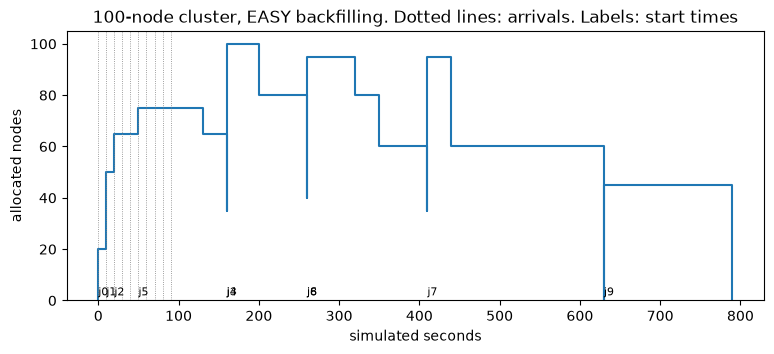

In [8]:
import matplotlib.pyplot as plt

res = pd.read_csv(OUT / "easy_res.csv")
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.step(res.time, res.allocated_nodes, where="post")
for _, j in sched.iterrows():
    ax.axvline(j.job_submit_time, color="grey", lw=0.6, ls=":")
    ax.annotate(f"j{int(j.job)}", (j.begin_time, 2), fontsize=8)
ax.set(xlabel="simulated seconds", ylabel="allocated nodes", ylim=(0, 105),
       title="100-node cluster, EASY backfilling. Dotted lines: arrivals. Labels: start times")
plt.show()

## Policy comparison in one loop, and a claim to verify by running

Three policies exist: `none` (strict FCFS, no backfilling), `easy`, `conservative` (every
waiting job gets a reservation). From reading the source, conservative backfilling is
implemented by a separate scheduler class selected by `--priority_policy
fcfs_conservative`; passing `--backfill_policy conservative` with the default `fcfs`
priority should silently run EASY. Do not trust that claim, test it.

In [9]:
configs = {
    "none":                              dict(backfill_policy="none",         priority_policy="fcfs"),
    "easy":                              dict(backfill_policy="easy",         priority_policy="fcfs"),
    "conservative + fcfs_conservative":  dict(backfill_policy="conservative", priority_policy="fcfs_conservative"),
    "conservative + fcfs (the trap)":    dict(backfill_policy="conservative", priority_policy="fcfs"),
}
rows = []
for name, cfg in configs.items():
    out = OUT / f"{cfg['backfill_policy']}_{cfg['priority_policy']}.csv"
    run_sim(TRACE, out, **cfg, **BASE)
    df = pd.read_csv(out)
    rows.append({"config": name,
                 "mean wait (s)": (df.begin_time - df.job_submit_time).mean(),
                 "makespan (s)": df.end_time.max(),
                 "begin times": list(df.begin_time)})
pd.DataFrame(rows)

,config,mean wait (s),makespan (s),begin times
0,none,184.0,790,"[0, 10, 20, 160, 160, 200, 260, 410, 440, 630]"
1,easy,151.0,790,"[0, 10, 20, 160, 160, 50, 260, 410, 260, 630]"
2,conservative + fcfs_conservative,168.0,790,"[0, 10, 20, 160, 160, 200, 260, 410, 280, 630]"
3,conservative + fcfs (the trap),151.0,790,"[0, 10, 20, 160, 160, 50, 260, 410, 260, 630]"


## Output-trace facts you will trip over

- The simulated-trace CSV has **no job id**. Rows are in job-store order (arrival order
  for a plain run) and jobs that never started are **omitted**, so positional matching
  breaks as soon as anything is dropped.
- Times are truncated to whole seconds unless you pass `--msec_output`.
- `exit_status` is always 0.
- The statistics block printed at the end counts a job as "completed" for the wait and
  turnaround averages as soon as it has **started**, and `utilization` is node-seconds
  over `total_nodes * makespan` with the time origin at 0, not at the first arrival. Never
  build service metrics from it; use the per-job CSV.

In [10]:
run_sim(TRACE, OUT / "easy_msec.csv", backfill_policy="easy", priority_policy="fcfs", msec_output=True, **BASE)
print((OUT / "easy_msec.csv").read_text().splitlines()[0:3])

['job_submit_time,begin_time,end_time,num_nodes,exit_status,time_limit', '0.000,0.000,200.000,20,0,200.000', '10.000,10.000,160.000,30,0,150.000']


## Tests, docs, CI: how a contribution is shaped

- Every suite is a shell runner `tests/run_<name>.sh` that finds `simulator` under
  `$CMAKE_INSTALL_PREFIX/bin` (falling back to `build/`), runs fixtures from
  `tests/test_traces/<suite>/`, and diffs against `*.expected_output.csv`.
- Python tests are plain scripts with a hand-rolled harness (`tests/test_python_api.py`),
  not pytest. `tests/test_grpc_single_coordinator.py` starts real servers on free ports.
- CI (`.github/workflows/tests.yml`) builds with Python and gRPC on for gcc and clang and
  runs each suite as its own step. A new suite means: a runner script, a CI step, and a
  section in `docs/TESTING_GUIDE.md`.
- Docs are MyST markdown under `docs/`, wired into the toctrees in `docs/index.md`.

Run the Python API test script against this install to confirm the environment is sane
(`tests/run_python_tests.sh` wraps it, but that wrapper needs bash 4).

In [11]:
env = dict(os.environ, PYTHONPATH=str(INSTALL / "lib" / "python"))
r = subprocess.run([sys.executable, "tests/test_python_api.py"], cwd=DR_EVT, env=env, capture_output=True, text=True)
print("\n".join(l for l in r.stdout.splitlines() if "Test Results" in l or "PASSED" in l or "✗" in l))

Test Results: 16/16 passed
✅ ALL PYTHON API TESTS PASSED!


## Exercises


1. Job 4 (25 nodes, submitted at t=40) fit in the 35 free nodes at t=40. Why did it start
   at t=160?
2. What does `--run_time_mode limit` mean, and what would change in the schedule above if
   job 1 actually ran for 60 s instead of its 150 s limit?
3. You add a new Python test script. What three files do you touch so it runs in CI and is
   documented?
4. Two jobs are rejected during a run. Why can you no longer tell which output row is which
   input job?
5. Which two CMake flags did CMake 4 force us to add, and what would have happened without
   the Boost one?